# 12 -- Region accessors and Boolean DSL

venn-diagram-lab exposes four small helpers for selecting items and
regions inside an analysed diagram. The accessors return Python lists
of item identifiers; the Boolean DSL parses a short expression like
`A & B + B & C` into a list of region bitmasks; and `render_venn_svg()`
can draw the actual item names inside each region or spotlight a
subset of regions on top of the diagram. The four chain naturally --
this notebook walks through each surface on the bundled cancer
drivers sample, then composes them end-to-end.

**Audience:** researchers who already analyse with venn-diagram-lab
and want quick access to per-region item lists or presentation-ready
spotlight renderings.

**You will learn:**

1. The three accessors -- `intersection_items`, `exclusive_items`,
   `union_items` -- and three research questions they answer.
2. The Boolean DSL grammar (`&`, `+`/`|`, `~`/`!`, parentheses,
   atoms `A..I`) with one example per operator class.
3. `render_venn_svg(..., show_items=True)` to draw item identifiers
   inside each region.
4. `render_venn_svg(..., highlight=...)` to spotlight selected regions
   in label form or bitmask form.
5. A composability chain: DSL expression -> mask list -> spotlight render.
6. The same operations from the shell via `vdl data items`,
   `vdl data regions`, and `vdl render venn --highlight-expr`.
7. A decision table for picking the right pattern.


In [1]:
import venn_diagram_lab as vdl
from IPython.display import SVG, display

ds = vdl.load_sample('dataset_real_cancer_drivers_4')
res = vdl.analyze(ds)

print('Set inclusive sizes (items per source catalog):')
for name, size in res.set_sizes.items():
    print(f'  {name:14s} {size:5d}')


Set inclusive sizes (items per source catalog):
  Vogelstein       138
  COSMIC_CGC       581
  OncoKB          1231
  IntOGen          633


## 1. Three accessors -- one for each membership question

Three pure functions, one for each of the most common questions about
set membership:

| Function | Question it answers |
|---|---|
| `intersection_items(result, sets)` | Which items appear in EVERY set in `sets`? (regardless of other memberships) |
| `exclusive_items(result, sets)` | Which items appear in EXACTLY this combination? (and in no other set) |
| `union_items(result, sets)` | Which items appear in ANY of these sets? (deduplicated) |

All three accept either set letters (`'A'`, `'B'`, ...) or display
names (the values of `result.dataset.set_names`); the two forms may
be mixed. Output ordering follows `dataset.item_order` for
deterministic, reproducible results.


### Research question 1 -- the four-way consensus

*Which cancer-driver genes are shared by Vogelstein, COSMIC_CGC, and
OncoKB?* This uses `intersection_items` because the question allows
membership in IntOGen too -- we just want items present in all three
named catalogs.


In [2]:
shared_three = vdl.intersection_items(
    res, ['Vogelstein', 'COSMIC_CGC', 'OncoKB']
)
print(f'Shared by all three named catalogs: {len(shared_three)} items')
print('First 10:', shared_three[:10])


Shared by all three named catalogs: 126 items
First 10: ['ABL1', 'ACVR1B', 'AKT1', 'ALK', 'APC', 'AR', 'ARID1A', 'ARID1B', 'ARID2', 'ASXL1']


### Research question 2 -- catalog-exclusive drivers

*Which drivers does Vogelstein list that no other catalog reports?*
This uses `exclusive_items` -- items present in Vogelstein and in NONE
of COSMIC_CGC, OncoKB, IntOGen.


In [3]:
vogelstein_only = vdl.exclusive_items(res, ['Vogelstein'])
print(f'Vogelstein-only drivers: {len(vogelstein_only)}')
print(vogelstein_only)


Vogelstein-only drivers: 7
['FAM123B', 'H3F3A', 'HIST1H3B', 'MLL2', 'MLL3', 'MYCL1', 'SKP2']


### Research question 3 -- the candidate pool

*Across Vogelstein and OncoKB combined, how big is the candidate gene
list?* This uses `union_items` to deduplicate across the two
catalogs.


In [4]:
candidate_pool = vdl.union_items(res, ['Vogelstein', 'OncoKB'])
print(f'Union of Vogelstein and OncoKB: {len(candidate_pool)} unique drivers')
print('First 10 in item_order:', candidate_pool[:10])


Union of Vogelstein and OncoKB: 1238 unique drivers
First 10 in item_order: ['A1CF', 'AAMP', 'ABCB1', 'ABCC3', 'ABI1', 'ABL1', 'ABL2', 'ABRAXAS1', 'ACACA', 'ACKR3']


## 2. Boolean DSL -- one operator at a time

`parse_region_expression(expr, n_sets)` translates a Boolean
expression into a sorted list of region bitmasks. The grammar uses
the standard precedence:

| Operator | Meaning | Precedence |
|---|---|---|
| `~` or `!` | Complement (unary) | highest |
| `&` | Intersection | middle |
| `+` or `|` | Union | lowest |
| `(`, `)` | Grouping | -- |

Atoms are uppercase letters `A..I`, one per set. For the 4-set
cancer-drivers diagram, A=Vogelstein, B=COSMIC_CGC, C=OncoKB,
D=IntOGen. Returned bitmasks are sorted and use the standard
convention bit 0 = set A.


### Atoms -- one letter per set


In [5]:
print('A   ->', vdl.parse_region_expression('A', n_sets=4))
print('D   ->', vdl.parse_region_expression('D', n_sets=4))


A   -> [1, 3, 5, 7, 9, 11, 13, 15]
D   -> [8, 9, 10, 11, 12, 13, 14, 15]


### Intersection (`&`) -- regions that include both sides


In [6]:
print('A & B       ->', vdl.parse_region_expression('A & B', n_sets=4))
print('A & B & C   ->', vdl.parse_region_expression('A & B & C', n_sets=4))
print('A & B & C & D ->', vdl.parse_region_expression('A & B & C & D', n_sets=4))


A & B       -> [3, 7, 11, 15]
A & B & C   -> [7, 15]
A & B & C & D -> [15]


### Union (`+` or `|`) -- regions that include either side


In [7]:
print('A + B ->', vdl.parse_region_expression('A + B', n_sets=4))
print('A | B ->', vdl.parse_region_expression('A | B', n_sets=4))


A + B -> [1, 2, 3, 5, 6, 7, 9, 10, 11, 13, 14, 15]
A | B -> [1, 2, 3, 5, 6, 7, 9, 10, 11, 13, 14, 15]


### Complement (`~` or `!`) -- regions that EXCLUDE the operand


In [8]:
print('~A ->', vdl.parse_region_expression('~A', n_sets=4))
print('!A ->', vdl.parse_region_expression('!A', n_sets=4))


~A -> [2, 4, 6, 8, 10, 12, 14]
!A -> [2, 4, 6, 8, 10, 12, 14]


### Parentheses + combined operators

`A & (B + C)` -- items in A AND in at least one of B or C. Note that
without parentheses, `A & B + C` would parse as `(A & B) + C` due to
intersection's higher precedence.


In [9]:
print('A & (B + C)     ->', vdl.parse_region_expression('A & (B + C)', n_sets=4))
print('(A | B) & C     ->', vdl.parse_region_expression('(A | B) & C', n_sets=4))
print('A & ~B & ~C & ~D ->', vdl.parse_region_expression('A & ~B & ~C & ~D', n_sets=4))


A & (B + C)     -> [3, 5, 7, 11, 13, 15]
(A | B) & C     -> [5, 6, 7, 13, 14, 15]
A & ~B & ~C & ~D -> [1]


### Unsatisfiable expressions return an empty list

Some expressions admit no region. The parser does not raise; it
returns `[]` so the result composes cleanly with downstream code.


In [10]:
print('A & ~A ->', vdl.parse_region_expression('A & ~A', n_sets=4))


A & ~A -> []


## 3. Drawing item names inside the regions (`show_items=True`)

`render_venn_svg(..., show_items=True)` replaces the per-region count
text with the actual item identifiers as multi-line `<tspan>`
content. Tune the layout via `item_options`:

| Key | Default | Effect |
|---|---|---|
| `max_items_per_region` | 20 | Cap items shown; the rest collapse to `+N more` |
| `ncol_items` | 1 | Wrap items into multiple columns |
| `truncate_long_names` | 12 | Trim long labels (0 disables) |
| `line_height` | 10 | tspan `dy` for each line |
| `font_size` | 8 | text font size |
| `show_counts_with_items` | False | If True, prepend a bold count |
| `ellipsis` | `'...'` | Suffix on truncated labels |

Below: render the cancer-drivers diagram with item names, capped at
6 per region so the dense 4-way intersection stays readable, with
labels truncated to 10 characters.


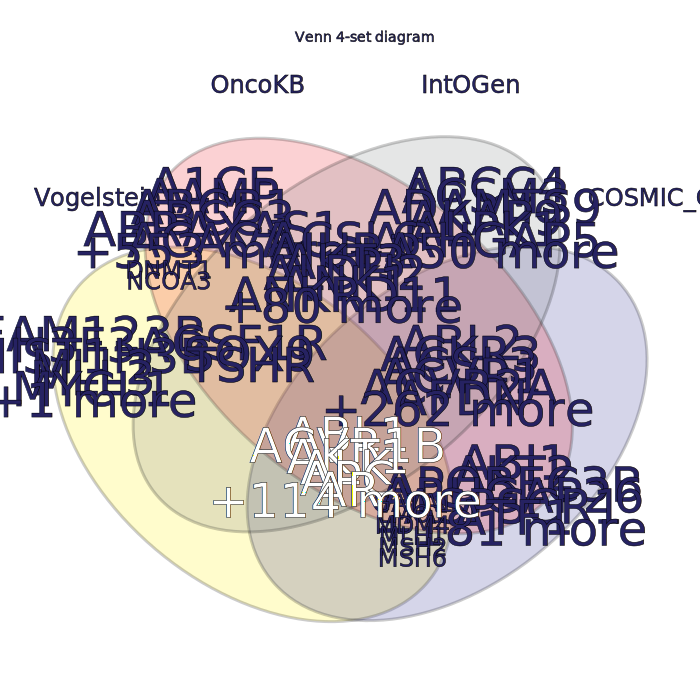

In [11]:
img = vdl.render_venn_svg(
    res,
    show_items=True,
    item_options={
        'max_items_per_region': 6,
        'truncate_long_names': 10,
        'line_height': 11,
    },
)
display(SVG(img.svg))


## 4. Spotlight mode (`highlight=...`)

`render_venn_svg(..., highlight=...)` desaturates every set shape
that does NOT contribute to at least one highlighted region.
Highlighted regions keep their original fill; the rest fade to
`#cccccc` at 25% opacity. The argument accepts EITHER a sequence of
region labels (`'AB'`, `'ABC'`, ...) OR a sequence of region
bitmasks (integers). The two forms are interchangeable -- use
whichever is more convenient.


### Label form -- spell out the regions of interest

Below: spotlight the AB and ABC regions of the 4-set diagram. C and
D shapes stay coloured because they contribute to ABC; D shape fades
because it does not contribute to either AB or ABC.


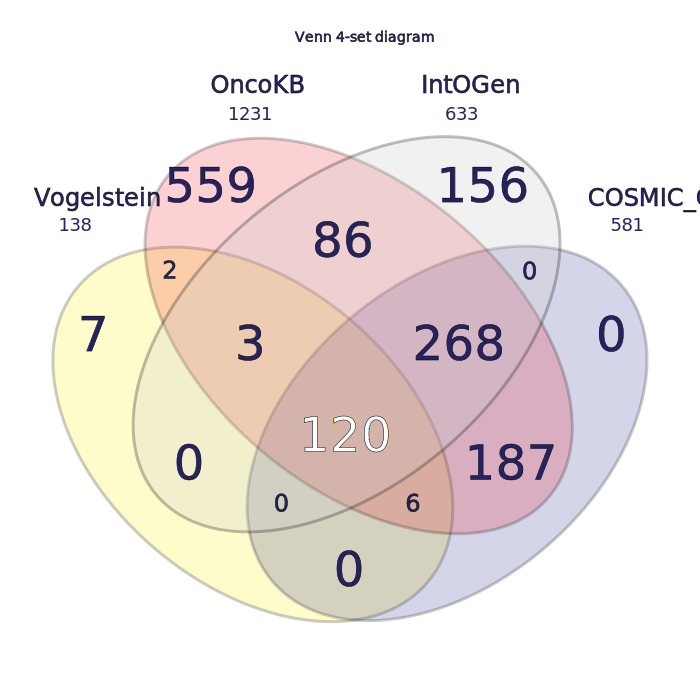

In [12]:
img = vdl.render_venn_svg(res, highlight=['AB', 'ABC'])
display(SVG(img.svg))


### Bitmask form -- use the DSL output directly

The Boolean DSL returns a list of integer bitmasks. Pass it straight
into `highlight=`. Below: spotlight every region where A and B BOTH
participate (i.e. masks AB, ABC, ABD, ABCD).


Highlighting masks: [3, 7, 11, 15]


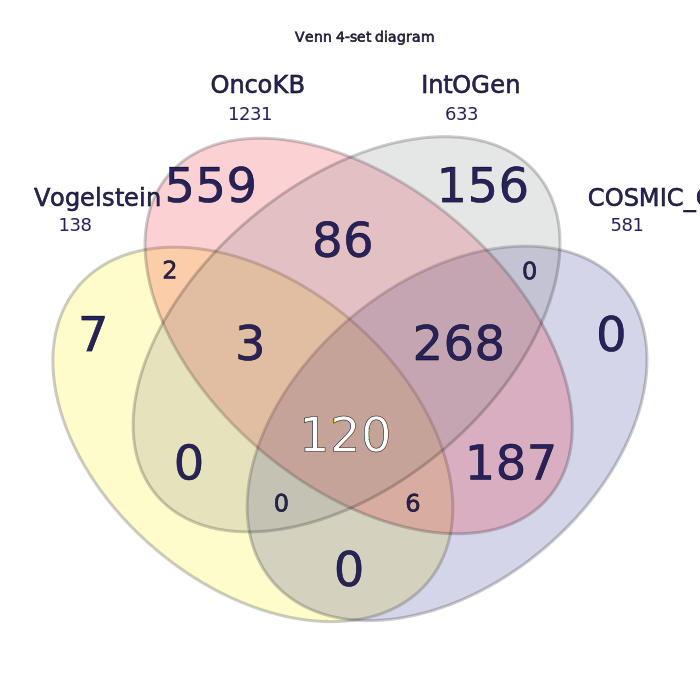

In [13]:
masks = vdl.parse_region_expression('A & B', n_sets=4)
print('Highlighting masks:', masks)
img = vdl.render_venn_svg(res, highlight=masks)
display(SVG(img.svg))


## 5. Composability -- one chain end to end

The four pieces compose: write a Boolean expression in the DSL,
get a mask list back, pass it to `highlight=`, and optionally turn
on `show_items=True` to also draw the gene names. The example
below highlights the genes that EITHER all-three Vogelstein + COSMIC
+ OncoKB share OR appear in COSMIC + OncoKB but NOT Vogelstein.


Expression  : 'A & B & C + ~A & B & C'
Mask list   : [6, 7, 14, 15]


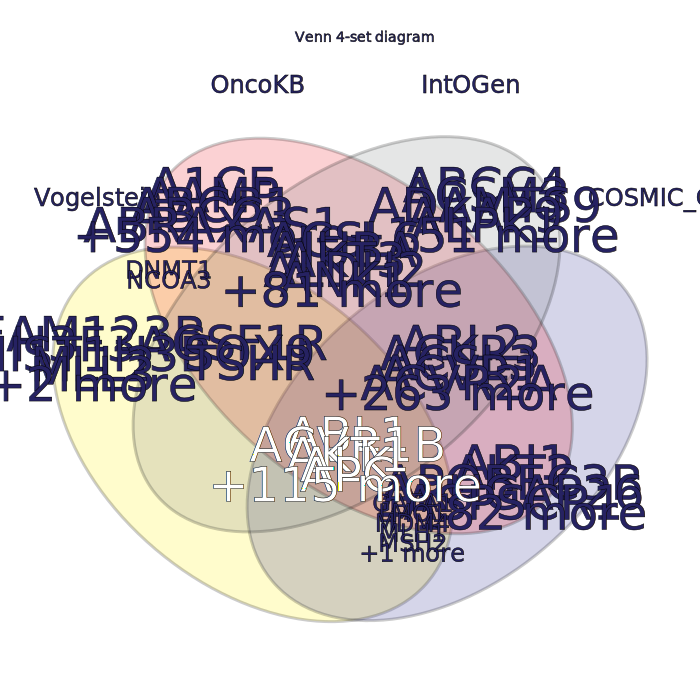

In [14]:
expr = 'A & B & C + ~A & B & C'
masks = vdl.parse_region_expression(expr, n_sets=4)
print(f'Expression  : {expr!r}')
print(f'Mask list   : {masks}')

img = vdl.render_venn_svg(
    res,
    highlight=masks,
    show_items=True,
    item_options={'max_items_per_region': 5, 'truncate_long_names': 9},
)
display(SVG(img.svg))


## 6. The same operations from the shell (`vdl`)

Every Python helper covered above is also a CLI subcommand. This
matters when you want a one-liner in a Snakemake rule, a Make
target, or an interactive shell. The notebook drives the CLI via
`subprocess.run` so the output is reproducible regardless of which
shell you usually use.


### `vdl data regions` -- resolve a Boolean expression to masks

Useful as a debug / validator and as a script-friendly way to get a
comma-separated mask list onto the shell.


In [15]:
import subprocess, sys
from pathlib import Path

VDL = str(Path(sys.executable).parent / 'vdl')

r = subprocess.run(
    [VDL, 'data', 'regions', '--expr', 'A & B + B & C', '--n-sets', '4'],
    capture_output=True, text=True, check=True,
)
print('masks  :', r.stdout.strip())

r = subprocess.run(
    [VDL, 'data', 'regions', '--expr', 'A & B + B & C',
          '--n-sets', '4', '--format', 'labels'],
    capture_output=True, text=True, check=True,
)
print('labels :', r.stdout.strip())


masks  : 3,6,7,11,14,15


labels : AB,BC,ABC,ABD,BCD,ABCD


### `vdl data items` -- list items by set combination

Three modes -- `intersection`, `exclusive`, `union` -- mirror the
Python accessors. Output is one item per line; use `--out -` for
stdout or `--out path.txt` for a file.


In [16]:
r = subprocess.run(
    [VDL, 'data', 'items', 'dataset_real_cancer_drivers_4',
          '--mode', 'exclusive', '--sets', 'A,B', '--out', '-'],
    capture_output=True, text=True, check=True,
)
items = r.stdout.splitlines()
print(f'Items exclusively in A and B (not in C or D): {len(items)}')
print('First 10:', items[:10])


Items exclusively in A and B (not in C or D): 0
First 10: []


### `vdl render venn --highlight-expr` -- spotlight render to file

Combines the DSL parsing and the spotlight render into one
command. The `--highlight-expr` flag is preferred over comma-list
`--highlight` when the expression is more complex than two or three
labels.


Wrote 8549 chars to spotlight.svg


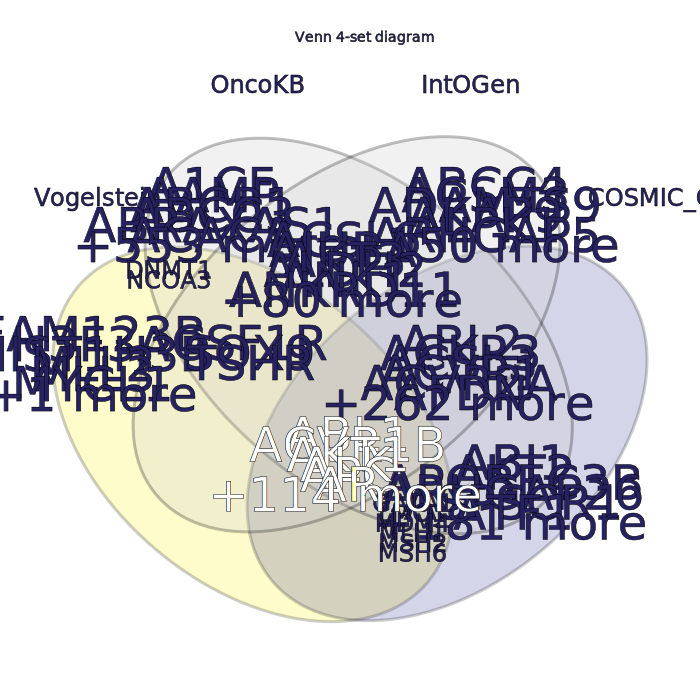

In [17]:
import tempfile

with tempfile.TemporaryDirectory() as tmp:
    out_path = Path(tmp) / 'spotlight.svg'
    r = subprocess.run(
        [VDL, 'render', 'venn', 'dataset_real_cancer_drivers_4',
              '--show-items', '--max-items-per-region', '6',
              '--truncate-long-names', '10',
              '--highlight-expr', 'A & B & ~C & ~D',
              '--out', str(out_path)],
        capture_output=True, text=True, check=True,
    )
    svg_text = out_path.read_text()
    print(f'Wrote {len(svg_text)} chars to {out_path.name}')
    display(SVG(svg_text))


## 7. Which pattern when?

| Use this | When |
|---|---|
| `intersection_items(res, [...])` | You want every item shared by a group, and you don't care whether items also appear in other sets. |
| `exclusive_items(res, [...])` | You want items ONLY in this exact combination. Equivalent to looking up one region. |
| `union_items(res, [...])` | You want a deduplicated candidate pool across a group. |
| `parse_region_expression(expr, n_sets)` | You want the mask vector for a non-trivial Boolean combination (with negation or unions). |
| `render_venn_svg(..., show_items=True)` | You want item names inside the regions for a paper figure or slide. |
| `render_venn_svg(..., highlight=[...])` | You want a spotlight on a subset of regions; other sets fade. |
| `vdl data items ... --out -` | Shell pipeline that needs the items (e.g. piped into another tool). |
| `vdl data regions --expr ...` | Debug / sanity-check a DSL expression without writing Python. |
| `vdl render venn --highlight-expr ...` | One-shot CLI render with a DSL spotlight, e.g. in a Makefile. |


## Further reading

- [`02_real_cancer_drivers.ipynb`](02_real_cancer_drivers.ipynb) -- the same dataset with the full analysis + report pipeline.
- [`05_statistics_deep_dive.ipynb`](05_statistics_deep_dive.ipynb) -- the statistics underlying which intersections are enriched.
- [`07_pdf_reports.ipynb`](07_pdf_reports.ipynb) -- bundle a spotlight render into a multi-page PDF report.
